In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_set = torchvision.datasets.CIFAR10(root='/kaggle/input/datasets/mikhail2434/cifar10', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='/kaggle/input/datasets/mikhail2434/cifar10', train=False, download=True, transform=transform)

train_subset = torch.utils.data.Subset(train_set, range(2000))
test_subset = torch.utils.data.Subset(test_set, range(500))

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False, num_workers=2)

num_classes = 10

In [4]:
def make_model(arch_fn, weights):
    model = arch_fn(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model.to(device)

teacher1 = make_model(models.resnet50, models.ResNet50_Weights.DEFAULT)
teacher2 = make_model(models.resnet101, models.ResNet101_Weights.DEFAULT)
teacher3 = make_model(models.resnet152, models.ResNet152_Weights.DEFAULT)

student = make_model(models.resnet50, models.ResNet50_Weights.DEFAULT)
simple_model = make_model(models.resnet50, models.ResNet50_Weights.DEFAULT)

list_models = [teacher1, teacher2, teacher3, simple_model]

print('Done')

Done


In [5]:
T = 4.0
alpha = 0.7

optimizer = torch.optim.Adam(student.parameters(), lr=1e-4)
teachers = [teacher1, teacher2, teacher3]
def get_ensemble_logits(x):
    with torch.no_grad():
        for t in teachers:
            t.eval()
        logits = [t(x) for t in teachers]
        avg_logits = torch.stack(logits, dim=0).mean(dim=0)
    return avg_logits

def distillation_loss(student_logits, teacher_logits, labels):
    soft_teacher = F.log_softmax(teacher_logits / T, dim=1)
    soft_student = F.log_softmax(student_logits / T, dim=1)
    kd_loss = F.kl_div(soft_student, soft_teacher, log_target=True, reduction='batchmean') * (T ** 2)
    ce_loss = F.cross_entropy(student_logits, labels)
    return alpha * kd_loss + (1 - alpha) * ce_loss

In [6]:
num_epoch = 2
history = {inxmodel: {'train_loss': []} for inxmodel in range(len(list_models))}
criterion = nn.CrossEntropyLoss()

for inxmodel, curr_model in enumerate(list_models):    
    print('current model:', inxmodel)
    curr_model.to(device)
    curr_model.train()
    
    optimizer = torch.optim.Adam(curr_model.parameters(), lr=1e-4)

    for ep in range(num_epoch):
        curr_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            logits = curr_model(images)

            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            curr_loss += loss.item()
            if i % 30 == 0:
                print(f'Epoch {ep+1}, step {i}, loss {loss.item():.4f}')

        avg_loss = curr_loss/len(train_loader)
        history[inxmodel]['train_loss'].append(avg_loss)
        print(f'Epoch {num_epoch} done, avg loss {avg_loss:.4f}')
for t in teachers:
    t.eval()

current model: 0
Epoch 1, step 0, loss 2.2981
Epoch 1, step 30, loss 1.8903
Epoch 1, step 60, loss 1.1092
Epoch 2 done, avg loss 1.7088
Epoch 2, step 0, loss 0.7836
Epoch 2, step 30, loss 0.3058
Epoch 2, step 60, loss 0.4471
Epoch 2 done, avg loss 0.5008
current model: 1
Epoch 1, step 0, loss 2.3054
Epoch 1, step 30, loss 1.4477
Epoch 1, step 60, loss 0.3864
Epoch 2 done, avg loss 1.3716
Epoch 2, step 0, loss 0.4478
Epoch 2, step 30, loss 0.0991
Epoch 2, step 60, loss 0.2597
Epoch 2 done, avg loss 0.2718
current model: 2
Epoch 1, step 0, loss 2.2749
Epoch 1, step 30, loss 1.3916
Epoch 1, step 60, loss 0.6580
Epoch 2 done, avg loss 1.3764
Epoch 2, step 0, loss 0.3115
Epoch 2, step 30, loss 0.1802
Epoch 2, step 60, loss 0.2349
Epoch 2 done, avg loss 0.2847
current model: 3
Epoch 1, step 0, loss 2.2983
Epoch 1, step 30, loss 1.7902
Epoch 1, step 60, loss 0.7232
Epoch 2 done, avg loss 1.6929
Epoch 2, step 0, loss 0.8172
Epoch 2, step 30, loss 0.2915
Epoch 2, step 60, loss 0.4298
Epoch 2 do

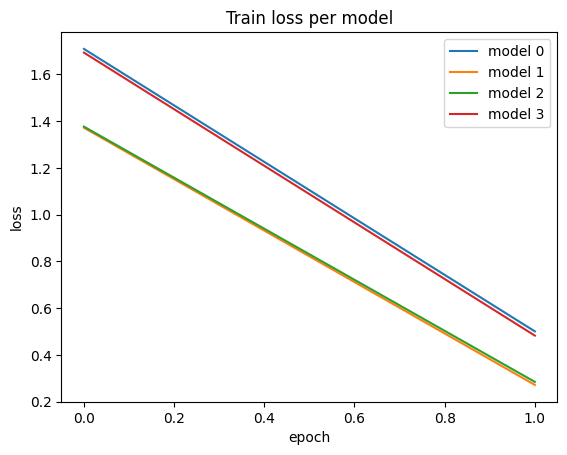

In [7]:
for inxmodel in history:
    plt.plot(history[inxmodel]['train_loss'], label=f'model {inxmodel}')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Train loss per model')
plt.show()

In [8]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


results = {}
for inxmodel, curr_model in enumerate(list_models):
    test_loss, test_acc = evaluate(curr_model, test_loader, criterion, device)
    results[inxmodel] = (test_loss, test_acc)
    print(f'Model {inxmodel}: test loss {test_loss:.4f}, test accuracy {test_acc:.4%}')

Model 0: test loss 0.4677, test accuracy 85.8000%
Model 1: test loss 0.3237, test accuracy 89.2000%
Model 2: test loss 0.4098, test accuracy 86.6000%
Model 3: test loss 0.4669, test accuracy 84.2000%


In [13]:
num_epochs = 5
history = {'student': {'train_loss': []}}
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(student.parameters(), lr=1e-4)

for ep in range(num_epochs):
    student.to(device)
    student.train()
    curr_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        teacher_logits = get_ensemble_logits(images)
        student_logits = student(images)

        loss = distillation_loss(student_logits, teacher_logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        curr_loss += loss.item()
    avg_loss = curr_loss/len(train_loader)
    history['student']['train_loss'].append(avg_loss)
    print(f'Epoch {ep} done, avg loss {avg_loss:.4f}')

Epoch 0 done, avg loss 2.9704
Epoch 1 done, avg loss 0.7134
Epoch 2 done, avg loss 0.3413
Epoch 3 done, avg loss 0.2256
Epoch 4 done, avg loss 0.1666


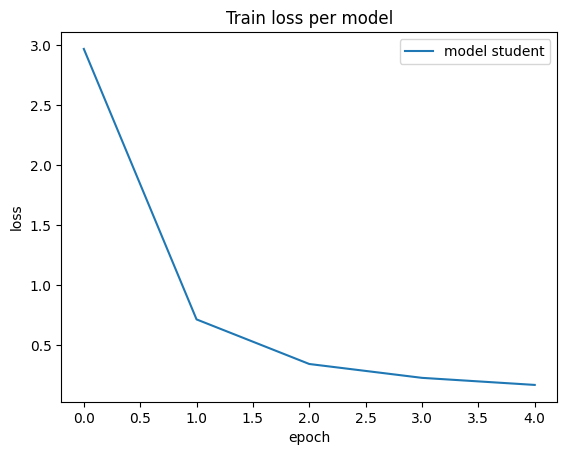

In [14]:
for inxmodel in history:
    plt.plot(history[inxmodel]['train_loss'], label=f'model {inxmodel}')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Train loss per model')
plt.show()

In [16]:
test_loss, test_acc = evaluate(student, test_loader, criterion, device)
print(f'Model ResNet50 as student: test loss {test_loss:.4f}, test accuracy {test_acc:.4%}')
test_loss, test_acc = evaluate(list_models[-1], test_loader, criterion, device)
print(f'Model ResNet50: test loss {test_loss:.4f}, test accuracy {test_acc:.4%}')

Model ResNet50 as student: test loss 0.3383, test accuracy 89.2000%
Model ResNet50: test loss 0.4669, test accuracy 84.2000%
